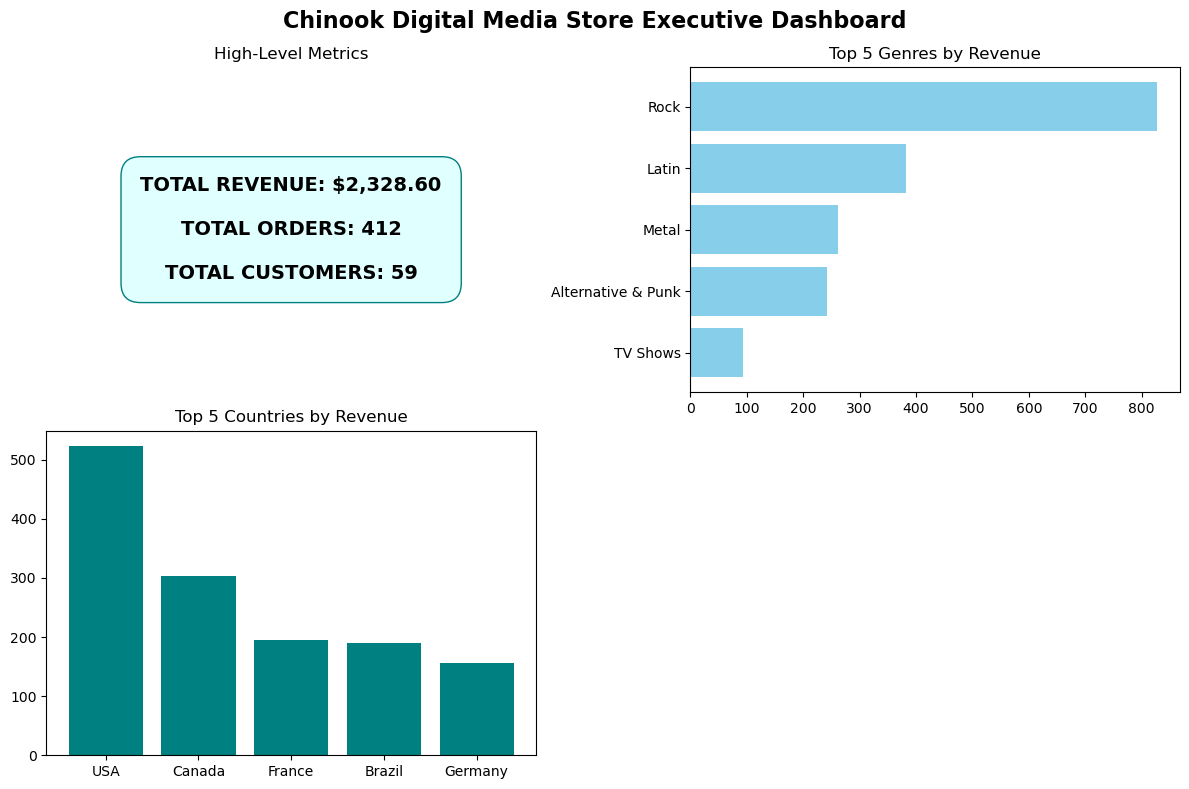

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect("Chinook_Sqlite.sqlite")

# Fetch Data
df_metrics = pd.read_sql_query("SELECT ROUND(SUM(Total), 2) AS Revenue, COUNT(InvoiceId) AS Orders, COUNT(DISTINCT CustomerId) AS Customers FROM Invoice;", conn)
df_genres = pd.read_sql_query("SELECT g.Name, ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS Revenue FROM InvoiceLine il JOIN Track t ON il.TrackId = t.TrackId JOIN Genre g ON t.GenreId = g.GenreId GROUP BY g.GenreId ORDER BY Revenue DESC LIMIT 5;", conn)
df_country = pd.read_sql_query("SELECT BillingCountry AS Country, ROUND(SUM(Total), 2) AS Revenue FROM Invoice GROUP BY BillingCountry ORDER BY Revenue DESC LIMIT 5;", conn)

# Create 2x2 Dashboard Figure
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Chinook Digital Media Store Executive Dashboard', fontsize=16, fontweight='bold')

# KPI Card Subplot
axs[0, 0].axis('off')
kpi_text = f"TOTAL REVENUE: ${df_metrics['Revenue'][0]:,.2f}\n\nTOTAL ORDERS: {df_metrics['Orders'][0]}\n\nTOTAL CUSTOMERS: {df_metrics['Customers'][0]}"
axs[0, 0].text(0.5, 0.5, kpi_text, ha='center', va='center', fontsize=14, fontweight='bold', bbox=dict(boxstyle="round,pad=1", facecolor="lightcyan", edgecolor="teal"))
axs[0, 0].set_title('High-Level Metrics')

# Top Genres Plot
axs[0, 1].barh(df_genres['Name'], df_genres['Revenue'], color='skyblue')
axs[0, 1].set_title('Top 5 Genres by Revenue')
axs[0, 1].invert_yaxis()

# Top Countries Plot
axs[1, 0].bar(df_country['Country'], df_country['Revenue'], color='teal')
axs[1, 0].set_title('Top 5 Countries by Revenue')

# Hide 4th empty quadrant
axs[1, 1].axis('off')

plt.tight_layout()

# Save dashboard image to project folder automatically!
plt.savefig('chinook_dashboard.png', dpi=300)
plt.show()